# GraphSAGE — learning how to aggregate a neighbourhood

This studybook explains GraphSAGE from first principles and then extends it to typed relations. It assumes you know what nodes, edges, features, and a one-hop neighbourhood are; notebook `02_project/00_graph_construction.ipynb` introduces those ideas visually. No project data is used here.

By the end, you should be able to derive a mean-aggregator layer, explain why it is inductive and permutation invariant, calculate a toy forward pass by hand, and read the relation-aware model used by this project.

Source: Hamilton, Ying, and Leskovec, [*Inductive Representation Learning on Large Graphs*](https://arxiv.org/abs/1706.02216), NeurIPS 2017.

## 1. Why GraphSAGE?

A table model receives one fixed row. A graph model can also consult a variable-size neighbourhood. GraphSAGE turns that neighbourhood into a fixed-size vector by applying a permutation-invariant aggregator, then combines it with the centre node's own state.

The crucial distinction is **inductive** learning. A lookup embedding says “node 17 owns this trainable vector” and has no principled vector for node 18 if it arrives tomorrow. GraphSAGE instead learns a function of observable features and neighbours. The same weights can be applied to a new node.

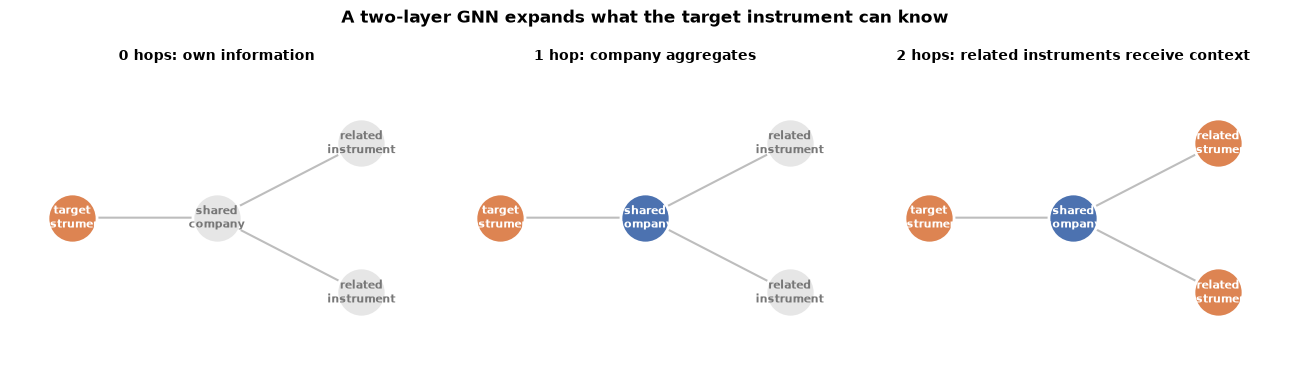

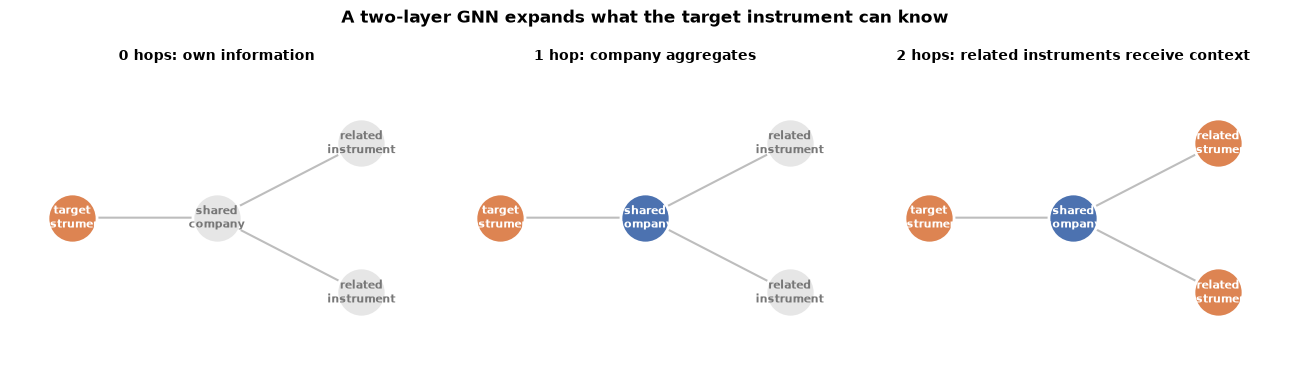

In [1]:
from graph_ml.viz import plot_message_passing_steps

plot_message_passing_steps()

## 2. One mean-aggregator layer

Let $h_v^{(k-1)}$ be node $v$'s input vector to layer $k$, and let $\mathcal{N}(v)$ be its neighbours. First aggregate the neighbours:

$$m_v^{(k)} = \operatorname{mean}_{u \in \mathcal{N}(v)} h_u^{(k-1)}.$$

Then transform the centre and neighbourhood separately, add them, and apply a nonlinearity:

$$h_v^{(k)} = \sigma\left(W_{self}^{(k)}h_v^{(k-1)} + W_{neigh}^{(k)}m_v^{(k)} + b^{(k)}\right).$$

The matrices are learned. `mean` has no trainable parameters; its job is to compress any number of neighbours without depending on their order. PyG's `SAGEConv` implements this form through a root transformation plus an aggregated-neighbour transformation.

### Calculate one update by hand

Suppose a centre node has scalar state 2 and two neighbours with states 1 and 3. Their mean is 2. If $W_{self}=0.5$, $W_{neigh}=1$, $b=0$, and $\sigma$ is ReLU, then the output is $0.5(2)+1(2)=3$.

In [2]:
import torch

centre = torch.tensor([2.0])
neighbours = torch.tensor([[1.0], [3.0]])
message = neighbours.mean(dim=0)
output = torch.relu(0.5 * centre + message)
{"neighbour_mean": message.item(), "updated_centre": output.item()}

{'neighbour_mean': 2.0, 'updated_centre': 3.0}

## 3. Why neighbour order must not matter

A graph has no canonical first neighbour or second neighbour. An aggregator must therefore be **permutation invariant**: shuffling a neighbourhood changes its storage order, not its meaning. Mean, sum, and max have this property; concatenating neighbours in arrival order does not.

In [3]:
forward = neighbours.mean(dim=0)
reversed_order = neighbours.flip(0).mean(dim=0)
assert torch.equal(forward, reversed_order)
"The mean is unchanged after reversing the neighbours."

'The mean is unchanged after reversing the neighbours.'

## 4. From GraphSAGE to relation-aware GraphSAGE

The original layer treats all edges as one semantic relation. In trade finance, `sold_by` and `owed_by` mean different things. The applied model therefore owns a separate `SAGEConv` for every typed relation and sums the resulting relation-specific vectors at each destination type:

$$h_v^{(k)} = \sigma\left(\sum_{r \in \mathcal{R}(v)} [W_{self,r}^{(k)}h_v^{(k-1)} + W_{neigh,r}^{(k)}m_{v,r}^{(k)}]\right).$$

```mermaid
flowchart LR
    IX[instrument features] -->|sold_by: SAGEConv| CH[company hidden state]
    IX -->|owed_by: SAGEConv| CH
    CX[company features] -->|sells: SAGEConv| IH[instrument hidden state]
    CX -->|owes: SAGEConv| IH
    CH -->|layer 2| IH2[instrument representation]
    IH -->|layer 2| CH2[company representation]
    IH2 --> MLP[impairment logit]
```

The self/root term inside each `SAGEConv` means no invented homogeneous self-loop relation is needed. Two layers give an instrument access to sibling instruments through their shared seller or buyer company.

## 5. Run the reusable model on a typed toy graph

The production model lives in `src/graph_ml/models/hetero_graphsage.py`. This graph has three instruments, three companies, and the same four directed relation stores as the real project graph. We ask for one logit per instrument; a logit is an unrestricted score before the sigmoid turns it into a probability.

In [4]:
from torch_geometric.data import HeteroData

from graph_ml.models import HeteroGraphSAGE

toy = HeteroData()
toy["instrument"].x = torch.tensor([[1.0, 0.0], [0.0, 1.0], [1.0, 1.0]])
toy["company"].x = torch.tensor([[1.0], [0.5], [0.0]])
toy["instrument", "sold_by", "company"].edge_index = torch.tensor([[0, 1, 2], [0, 1, 0]])
toy["instrument", "owed_by", "company"].edge_index = torch.tensor([[0, 1, 2], [1, 2, 2]])
toy["company", "sells", "instrument"].edge_index = toy["instrument", "sold_by", "company"].edge_index.flip(0)
toy["company", "owes", "instrument"].edge_index = toy["instrument", "owed_by", "company"].edge_index.flip(0)

torch.manual_seed(42)
model = HeteroGraphSAGE(2, 1, hidden_channels=8, dropout=0.0)
logits = model(toy.x_dict, toy.edge_index_dict)
{"logit_shape": tuple(logits.shape), "parameter_count": sum(p.numel() for p in model.parameters())}

{'logit_shape': (3,), 'parameter_count': 457}

## 6. The actual computational graph

A conceptual diagram states our intent; `torchview` traces the model that actually runs. The wrapper only converts six positional tensors into the dictionaries expected by PyG. Rounded boxes are operations/modules and arrows show tensor flow. Repeated relation branches are real independent parameter sets, not decorative copies.

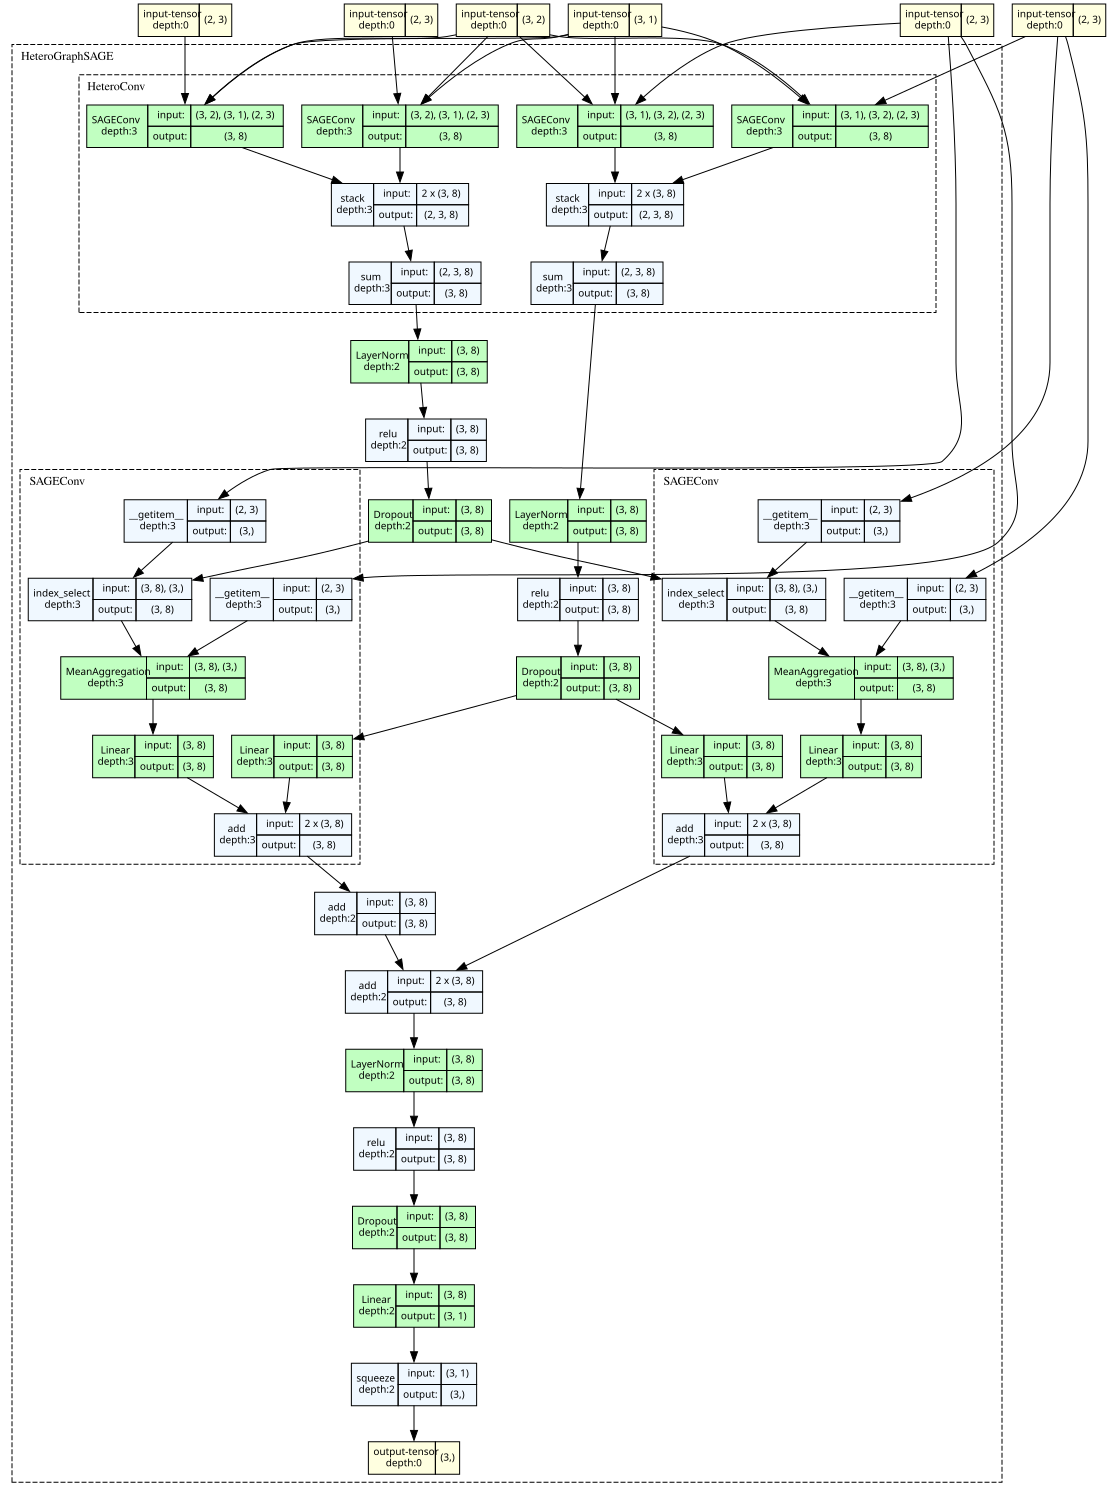

In [5]:
from torch import nn
from torchview import draw_graph

class TraceableGraphSAGE(nn.Module):
    def __init__(self, traced_model):
        super().__init__()
        self.model = traced_model

    def forward(self, instrument_x, company_x, sold_by, owed_by, sells, owes):
        return self.model(
            {"instrument": instrument_x, "company": company_x},
            {
                ("instrument", "sold_by", "company"): sold_by,
                ("instrument", "owed_by", "company"): owed_by,
                ("company", "sells", "instrument"): sells,
                ("company", "owes", "instrument"): owes,
            },
        )

model_graph = draw_graph(
    TraceableGraphSAGE(model),
    input_data=(
        toy["instrument"].x, toy["company"].x,
        toy["instrument", "sold_by", "company"].edge_index,
        toy["instrument", "owed_by", "company"].edge_index,
        toy["company", "sells", "instrument"].edge_index,
        toy["company", "owes", "instrument"].edge_index,
    ),
    graph_name="Relation-aware GraphSAGE",
    expand_nested=True,
    depth=3,
)
model_graph.visual_graph

## 7. What this model can and cannot test

Two layers are intentionally modest. They test whether learned same-company aggregation adds value beyond a row-wise model. They do not reach the longer buyer→hybrid→buyer paths needed for a genuine contagion claim. Increasing depth is not automatically better: repeated averaging can make node states indistinguishable (**over-smoothing**) and widens the surface for temporal leakage.

The first project run therefore uses two layers, relation-specific mean aggregation, full-batch CPU training, layer normalization, dropout, class-weighted binary cross-entropy, and temporal early stopping. Each choice is a controlled starting point, not a claim that GraphSAGE is the final architecture.

## Takeaways

- GraphSAGE learns an aggregation function, so it can represent unseen nodes from features and neighbourhoods.
- Mean aggregation is permutation invariant and separates the centre transformation from the neighbour transformation.
- Relation-aware GraphSAGE assigns different parameters to seller, buyer, and reverse message flows.
- Two layers expose an instrument to same-company siblings; longer contagion paths remain outside this vertical slice.
- Architecture diagrams explain intent, while the traced computational graph checks what the code actually executes.